# Process published DZ datasets

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geoscripts.dz import dz

/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/mpltern/ternary/datasets.py:9: UserWarning: `mpltern.ternary.datasets.py` has been moved to `mpltern.datasets.py` and will be removed from the present directory in mpltern 0.6.0.
  warnings.warn(msg)
2025-01-17 11:55:56,932 pyrolite.util.plot.helpers - WARNING: scikit-learn not installed


In [16]:
# Domenech
meta = pd.read_excel('published_data/Domenech_ter12340-sup-0003-tables1.xlsx',header=1,index_col=0)

print(meta)

raw = pd.read_excel('published_data/Domenech_ter12340-sup-0004-tables2.xlsx',header=None,index_col=0,skiprows=1)
raw.columns = raw.iloc[0].fillna('') + ' ' + raw.iloc[1]
raw.drop(raw.iloc[0:2,:].index,inplace=True)

print(raw.columns)

       Longitude   Latitude  Elevation (m) Lithologic unit     Lithology  \
Sample                                                                     
Mi39T   8.2929ºW  30.9094ºN           1716     F5b (upper)     Sandstone   
Mi40T   8.2957ºW  30.9166ºN           1584     F5b (lower)     Sandstone   
Mi48T   8.3126ºW  30.9142ºN           1876     F5a (lower)     Sandstone   
Mi49T   8.3340ºW  30.8985ºN           2061              F3  Conglomerate   
Mi63T   8.2927ºW  30.9259ºN           1371     F5b (upper)     Sandstone   

              Depositional age  
Sample                          
Mi39T                  Carnian  
Mi40T                  Carnian  
Mi48T       Anisian to Carnian  
Mi49T   Triassic (pre‐Anisian)  
Mi63T                  Carnian  
Index([' [U] ppm', ' U/Th', ' 207/235', ' 2σ error', ' 206/238', ' 2σ error',
       ' RHO', '207/235 Age Ma', ' 2σ error', '206/238 Age (Ma)', ' 2σ error',
       '207/206 Age (Ma)', ' 2σ error', 'Best age (Ma)', ' 2σ error',
       ' 

In [ ]:
# Extract individual samples and save to list
smps = []
for name in meta.index:
    print(name)
    data = raw[raw.index.str.startswith(name)]
    lat = float(meta.loc[name,'Latitude'][0:-2])
    lon = -float(meta.loc[name,'Longitude'][0:-2]) # negative for west
    smp = dz.DZSample(name=name,latlon=(lat,lon),agedata=data)
    smps.append(smp)

In [ ]:
# Calculate best ages and plot KDEs
fig,axs = plt.subplots(len(smps),figsize=(6.5,len(smps)*1.5),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.calc_bestage(col_238='206/238 Age (Ma)',col_207='207/206 Age (Ma)')
    smp.bestage = smp.bestage.astype(float) # Need to fix source code so this isn't necessary
    smp.kde(ax=ax,bw_adjust=0.2)
    ax.set_xlim(200,3500)
    ax.set_title(smp.name)
    smp.save()

plt.tight_layout()
fig.savefig('Domenech_kdes.pdf')

In [19]:
# Prep data for IsoplotR
output = 'isoplotr/input_data/'
ages_df = pd.DataFrame()
os.makedirs(output,exist_ok=True)

for smp in smps:
    iso_data = smp.agedata.iloc[:,2:7]
    iso_cols = ['75','75_err','68','68_err','rho']
    iso_data.columns = iso_cols
    iso_data.to_csv(output+smp.name+'.csv',index=False)

    # Ages for detritals file
    smp_ages = smp.agedata['Best age (Ma)'].reset_index(drop=True)
    smp_ages.name = smp.name
    ages_df = pd.concat([ages_df,smp_ages],axis=1)


ages_df.to_csv(output+'domenech_ages.csv',index=False)

In [8]:
# Perez
meta = pd.read_excel('published_data/Perez_tect21081-sup-0002-tect21081-sup-0001-2018tc005413-s01-s02_rev.xlsx',header=0,index_col=0,sheet_name='TABLE S1 Location Information')

print(meta)

raw = pd.read_excel('published_data/Perez_tect21081-sup-0002-tect21081-sup-0001-2018tc005413-s01-s02_rev.xlsx',header=None,index_col=0,sheet_name='TABLE S2 Zircon U-Pb results')
raw.columns = raw.iloc[0].fillna('') + ' ' + raw.iloc[1]
raw.drop(raw.iloc[0:2,:].index,inplace=True)
raw.dropna(how='all',inplace=True)

print(raw.columns)

                 Region   Latitude  Longitude   Age, Formation  \
Sample Name                                                      
01MCO        High Atlas  31.302239  -7.397644       Ouarzazate   
02MCO        High Atlas  31.299927  -7.390774         Cambrian   
03MCO        High Atlas  31.314573  -7.374777       Ordovician   
04MCO        High Atlas  31.319265  -7.378882       Ordovician   
05MCO        High Atlas  31.282763  -7.585985         Cambrian   
06MCO        High Atlas  31.285780  -7.590401     Triassic F5    
07MCO        High Atlas  31.297929  -7.589787     Triassic F3    
08MCO        High Atlas  31.311378  -7.561911     Triassic F5    
09MCO        High Atlas  31.309353  -7.601391     Triassic F5    
10MCO        High Atlas  31.354861  -7.756812     Triassic F3    
11MCO        High Atlas  31.353003  -7.756067       Permian F2   
12MCO        High Atlas  31.323831  -7.758938    Carboniferous   
13MCO        High Atlas  31.212034  -7.849956     Triassic F5    
14MCO     

In [9]:
# Extract individual samples and save to list
smps = []
for name in meta.index:
    print(name)
    data = raw[raw.index.str.contains(name)]
    lat = float(meta.loc[name,'Latitude'])
    lon = float(meta.loc[name,'Longitude'])
    smp = dz.DZSample(name=name,latlon=(lat,lon),agedata=data)
    smps.append(smp)

01MCO
02MCO
03MCO
04MCO
05MCO
06MCO
07MCO
08MCO
09MCO
10MCO
11MCO
12MCO
13MCO
14MCO
15MCO
16MCO


/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.agedata.loc[:,'Discordance'] = discordance
/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.agedata.loc[:,'Discard'] = discard
/home/dyvasey/miniforge3/envs/dataset-morocco-dz-2024/lib/python3.11/site-packages/geoscripts/dz/dz.py:71: SettingWith

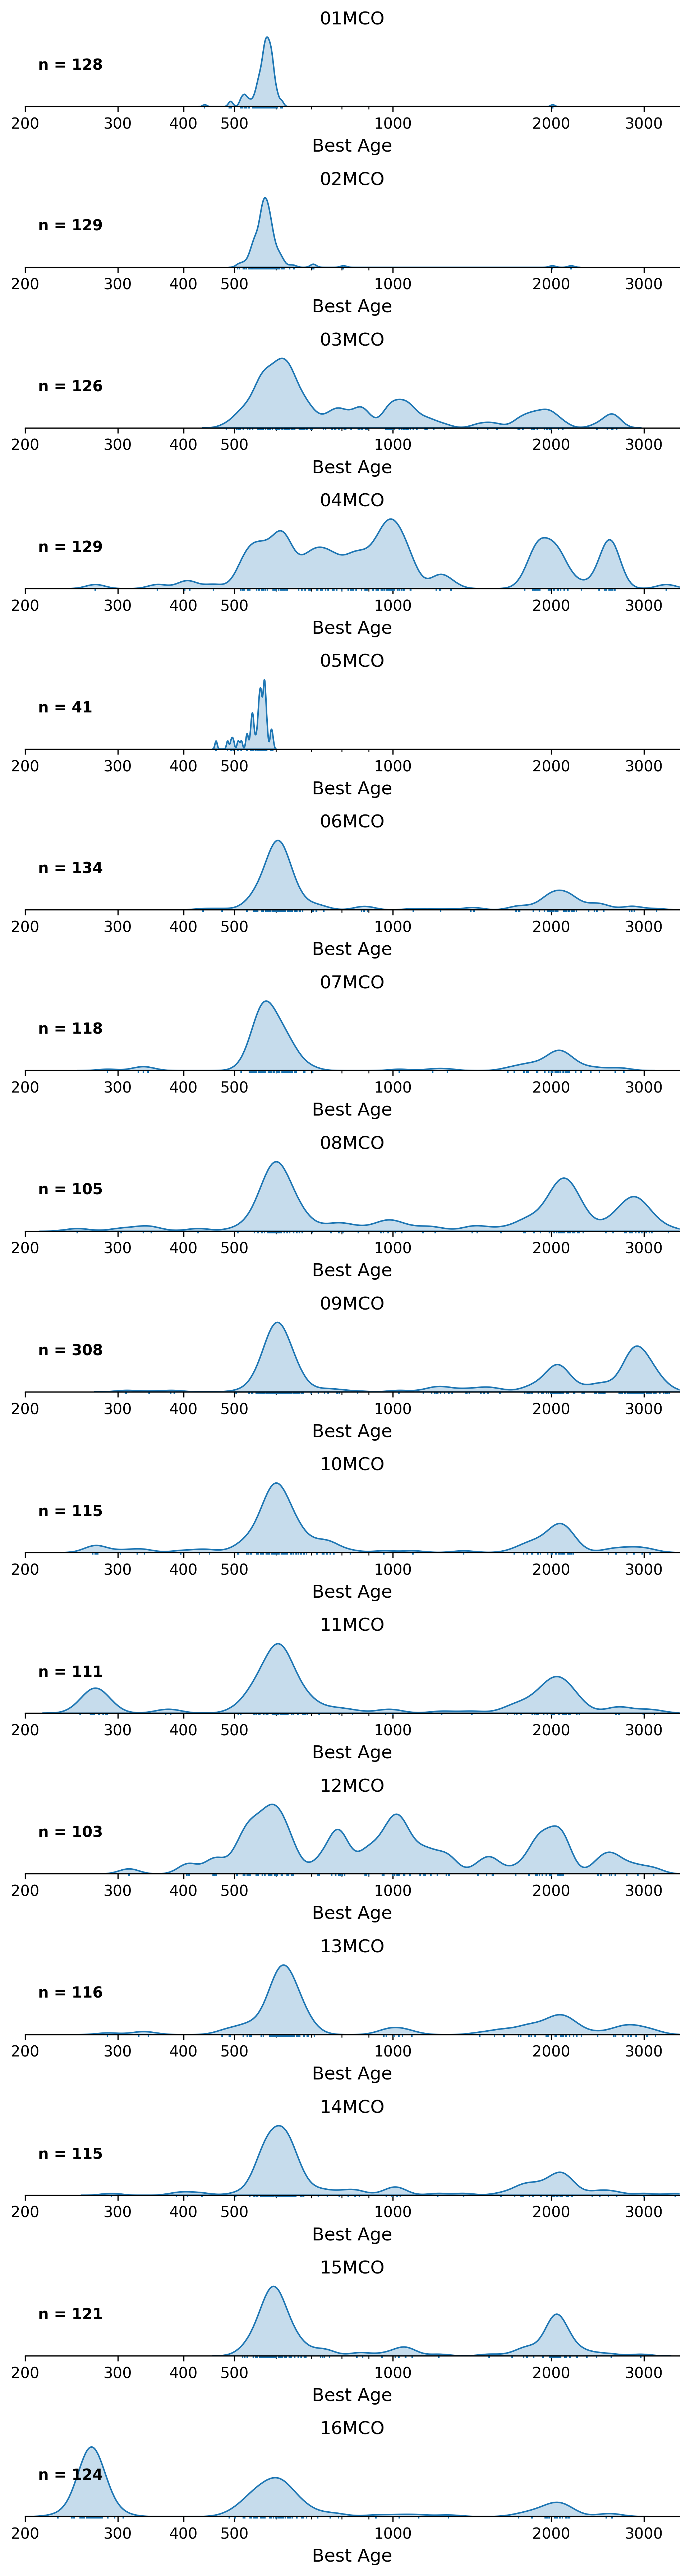

In [11]:
# Calculate best ages and plot KDEs
fig,axs = plt.subplots(len(smps),figsize=(6.5,len(smps)*1.5),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.calc_bestage(col_238='206/238  Age (Ma)',col_207='207/206 Age (Ma)')
    smp.bestage = smp.bestage.astype(float) # Need to fix source code so this isn't necessary
    smp.kde(ax=ax,bw_adjust=0.2)
    ax.set_xlim(200,3500)
    ax.set_title(smp.name)
    smp.save()

plt.tight_layout()
fig.savefig('Perez_kdes.pdf')

In [13]:
# Prep data for IsoplotR
output = 'isoplotr/input_data/'
ages_df = pd.DataFrame()
os.makedirs(output,exist_ok=True)

for smp in smps:
    iso_data = smp.agedata.iloc[:,2:7]
    iso_cols = ['75','75_err','68','68_err','rho']
    iso_data.columns = iso_cols
    iso_data.to_csv(output+smp.name+'.csv',index=False)

    # Ages for detritals file
    smp_ages = smp.agedata['Best age (Ma)'].reset_index(drop=True)
    smp_ages.name = smp.name
    ages_df = pd.concat([ages_df,smp_ages],axis=1)


ages_df.to_csv(output+'perez_ages.csv',index=False)